# 1교시 시연 — 데이터로 보는 세상 🌍✨

> **이 노트북은 강사 시연용입니다.** 모든 셀이 🔵(수업 중 함께 보는 셀)이에요.
> 코드를 외울 필요 **전혀 없습니다.** "데이터를 가져와 → 화려한 그림으로 보고 → 질문을 던진다"는 *흐름*만 느끼면 됩니다.
> (코드 한 줄 한 줄은 2교시부터 천천히 배웁니다.)

**오늘 구경할 데이터의 세계** — 단 몇 줄로 이 모든 걸 그려봅니다:
1. 💰 **비트코인·금** — 돈의 흐름
2. 🏠 **전국 아파트 실거래가** — 강사의 현장 데이터 (5.7만 건!)
3. 🌍 **세계 행복 보고서 2025** — 어느 나라가 가장 행복할까? 한국은?
4. ⚽ **국제 축구 150년** — 한국 대표팀 1,008경기 (5교시 캡스톤 예고)

> 예전엔 데이터 하나 구하는 것도 큰일이었습니다. 지금은 **몇 줄이면** 세상의 데이터가 손안에 들어옵니다.

## 0. 준비 — 도구 + 한글 폰트 + 데이터 한 번에 불러오기 🔵

아래 셀 하나로 (1) 그리기 도구, (2) 한글 폰트(깨짐 방지), (3) 오늘 쓸 데이터 5종을 모두 준비합니다.
**인터넷에서 자동으로 받아오므로** 강의장 어디서든(코랩 포함) 바로 돌아갑니다.

In [1]:
# === 데이터 로드 설정 (로컬/코랩 자동) ===
import os, urllib.request
DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"
def data_path(fname):
    for _p in ("../data/" + fname, "data/" + fname):
        if os.path.exists(_p):
            return _p
    return DATA_BASE + fname

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 한글 폰트(배민 도현체): 없으면 자동 다운로드, 실패해도 에러 없이 진행
def set_korean_font():
    _cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]
    if not any(os.path.exists(p) for p in _cands):
        try: urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")
        except Exception: pass
    for p in _cands:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()
                plt.rcParams["axes.unicode_minus"] = False
                return
            except Exception: pass
    print("(안내) 한글 폰트 미발견 — 영문 라벨은 정상.")
set_korean_font()
plt.rcParams["figure.dpi"] = 110   # 조금 더 선명하게

print("준비 완료! 이제 데이터의 세계로 들어갑니다 ✨")

준비 완료! 이제 데이터의 세계로 들어갑니다 ✨


## 1. 💰 비트코인 — 몇 줄로 가져와 화려하게 그리기 🔵

먼저 비트코인 시세입니다. 표로 보면 숫자만 빼곡하지만, **그림으로 바꾸는 순간** 이야기가 보입니다.

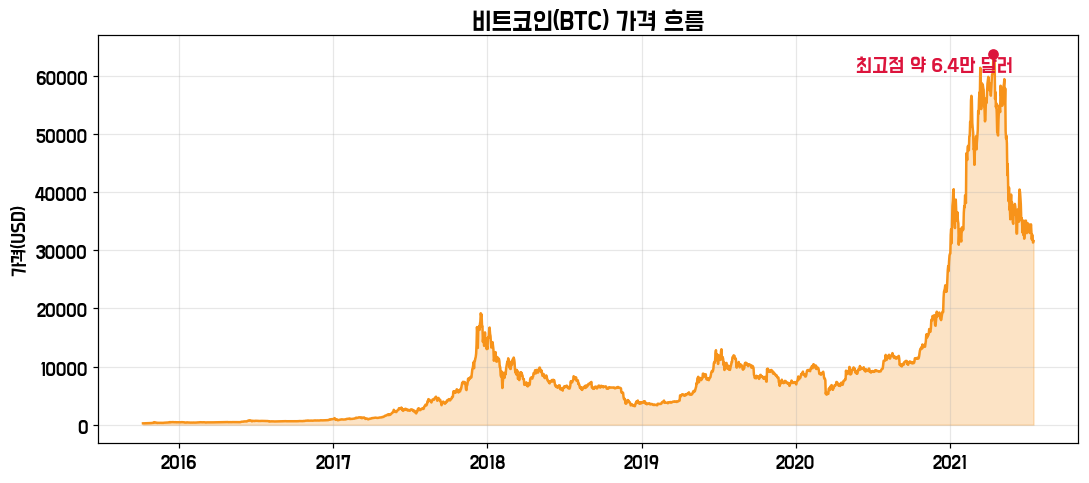

기간: 2015-10 ~ 2021-07
시작 $244  →  최고점 $63,773  (약 262배!)


In [2]:
btc = pd.read_csv(data_path("btc_usd_daily.csv"), skiprows=1)  # CSV 읽기 (맨 윗줄은 설명이라 건너뜀)
btc["Date"] = pd.to_datetime(btc["Date"])                     # 'Date' 칸을 글자 → 진짜 날짜형으로
btc = btc.sort_values("Date")                                 # 날짜 오름차순 정렬 (선그래프는 시간순이어야)

peak = btc.loc[btc["Close"].idxmax()]   # 종가(Close)가 가장 높은 '날의 행' = 최고점

plt.figure(figsize=(10, 4.5))                                             # 그림 캔버스 (가로10·세로4.5)
plt.fill_between(btc["Date"], btc["Close"], color="#F7931A", alpha=0.25)  # 선 아래를 옅은 주황으로 채움
plt.plot(btc["Date"], btc["Close"], color="#F7931A", linewidth=1.6)       # 가격 선 그리기
plt.scatter(peak["Date"], peak["Close"], color="crimson", zorder=5)       # 최고점 위치에 빨간 점
plt.annotate(f"최고점 약 {peak['Close']/10000:.1f}만 달러",                 # 최고점에 글자 (만 달러 단위로 표기)
             xy=(peak["Date"], peak["Close"]),                            #   글자가 가리킬 좌표(최고점)
             xytext=(-90, -10), textcoords="offset points", color="crimson", fontsize=11)  # 점에서 살짝 왼쪽·아래로
plt.title("비트코인(BTC) 가격 흐름", fontsize=14)   # 그래프 제목
plt.ylabel("가격(USD)"); plt.grid(alpha=0.3)        # y축 이름 + 옅은 격자
plt.tight_layout(); plt.show()                      # 여백 정리 후 화면에 출력

print(f"기간: {btc['Date'].min():%Y-%m} ~ {btc['Date'].max():%Y-%m}")  # 데이터가 다루는 기간
print(f"시작 ${btc['Close'].iloc[0]:,.0f}  →  최고점 ${peak['Close']:,.0f}  (약 {peak['Close']/btc['Close'].iloc[0]:.0f}배!)")  # 시작값 대비 몇 배인지

**무엇이 보이나요?** 숫자 표였다면 절대 못 느꼈을 **롤러코스터 같은 흐름**이 한눈에 들어옵니다.
시작값의 무려 *260배*까지 치솟았다가 다시 꺾이는 모습 — 이게 4교시에서 배울 **시각화의 힘**입니다.

## 2. 🥇 금(Gold) 시세 — 데이터만 바꾸면 끝 🔵

데이터가 바뀌어도 **방법은 똑같습니다**: 불러오기 → 그림. 이번엔 금 시세예요.

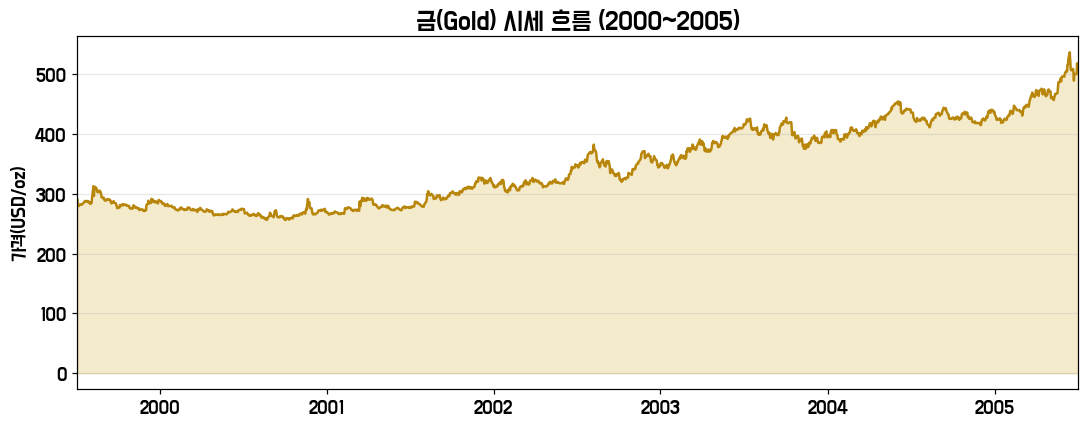

2000년 $290  →  2005년 $513


In [3]:
gold = pd.read_csv(data_path("gold_5y.csv"))   # 금 시세 CSV 읽기
gold["ds"] = pd.to_datetime(gold["ds"])        # 'ds'(날짜) 칸을 날짜형으로 변환

import matplotlib.dates as mdates                                     # 날짜 축 눈금을 다루는 도구
plt.figure(figsize=(10, 4))                                           # 캔버스 크기
plt.fill_between(gold["ds"], gold["y"], color="#D4AF37", alpha=0.25)  # 선 아래를 옅은 금색으로 채움
plt.plot(gold["ds"], gold["y"], color="#B8860B", linewidth=1.6)       # 금값 선 그리기
plt.title(f"금(Gold) 시세 흐름 ({gold['ds'].min():%Y}~{gold['ds'].max():%Y})", fontsize=14)  # 제목에 실제 연도범위 자동 표기
plt.ylabel("가격(USD/oz)"); plt.grid(axis="y", alpha=0.3)   # y축 이름(온스당 달러) + 가로 격자
plt.xlim(gold["ds"].min(), gold["ds"].max())      # x축을 데이터 범위(2000~2005)에 딱 맞춤
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(month=7))   # 연도 눈금을 '그 해 한가운데(7월)'에 → 라벨이 그 해 데이터 중앙에 옴(2005가 끝처럼 안 보이게)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # 눈금 라벨을 연도(예: 2005)로 표시
plt.tight_layout(); plt.show()
print(f"{gold['ds'].min():%Y}년 ${gold['y'].iloc[0]:,.0f}  →  {gold['ds'].max():%Y}년 ${gold['y'].iloc[-1]:,.0f}")  # 처음값 → 마지막값

비트코인과 똑같은 코드 패턴(`불러오기 → plot`)이죠? **대상이 무엇이든 분석의 문법은 같습니다.**
도구를 한 번 익히면 주식·환율·기온·매출… 무엇에든 그대로 씁니다.

## 3. 🏠 전국 아파트 실거래가 — 진짜 현장 데이터 🔵

이건 **국토교통부가 공개하는 진짜 거래 기록**입니다 (2021년 5월, 전국 **5.7만 건**).
실제 데이터는 처음엔 늘 *지저분*합니다 — 그걸 길들이는 게 분석가의 일이죠.

In [4]:
apt = pd.read_csv(data_path("apt_realprice_202105.csv"))   # 국토부 실거래가 CSV 읽기
print("거래 건수:", f"{len(apt):,}", "건")                  # 전체 행(row) 수 = 거래 건수
apt[["시군구", "단지명", "전용면적(㎡)", "거래금액(만원)"]].head(3)   # 주요 4개 칸만 위 3줄 미리보기

거래 건수: 57,805 건


,시군구,단지명,전용면적(㎡),거래금액(만원)
0,강원도 강릉시 견소동,송정한신,84.945,"19,500"
1,강원도 강릉시 견소동,송정한신,84.945,"19,500"
2,강원도 강릉시 견소동,송정한신,84.945,"19,500"


표의 `거래금액(만원)` 칸을 보세요 — `"19,500"` 처럼 **쉼표가 든 글자**라 이대로는 평균도 못 구합니다.
딱 한 줄로 숫자로 바꾼 뒤(자세한 정제는 **3교시**!), *"어느 동네가 비쌀까?"* 를 그려봅니다.

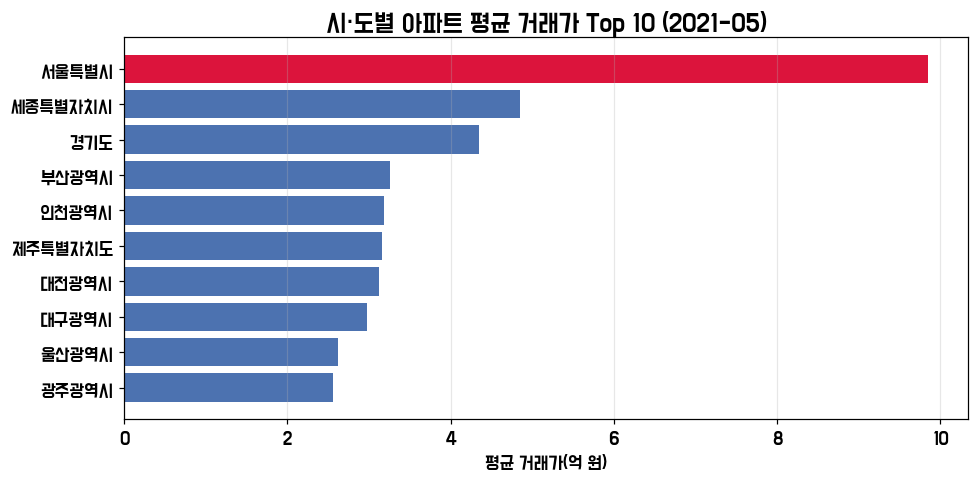

전국 평균: 3.51억  vs  중앙값: 2.45억


In [5]:
# 쉼표 제거 → 숫자로 (정제 맛보기, 자세히는 3교시)
apt["금액"] = apt["거래금액(만원)"].str.replace(",", "").astype(int)  # "19,500"(글자) → 19500(숫자)
apt["시도"] = apt["시군구"].str.split().str[0]                        # 시군구를 띄어쓰기로 나눈 첫 단어 = 시·도

top = (apt.groupby("시도")["금액"].mean() / 10000).sort_values(ascending=False).head(10)  # 시도별 평균(만원)→억, 높은순 10개
colors = ["crimson" if v == top.max() else "#4C72B0" for v in top.values]                 # 최댓값(1위)만 빨강, 나머지 파랑

plt.figure(figsize=(9, 4.5))
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])   # 가로 막대 ([::-1]=뒤집어 1위가 맨 위로)
plt.title("시·도별 아파트 평균 거래가 Top 10 (2021-05)", fontsize=14)
plt.xlabel("평균 거래가(억 원)"); plt.grid(axis="x", alpha=0.3)   # x축 이름 + 세로 격자
plt.tight_layout(); plt.show()

print(f"전국 평균: {apt['금액'].mean()/10000:.2f}억  vs  중앙값: {apt['금액'].median()/10000:.2f}억")  # 평균 vs 중앙값 (평균의 함정 복선)

**서울이 압도적(약 9.8억)** 으로 1위네요. 그런데 마지막 줄을 보세요 —
전국 **평균 3.5억** 인데 **중앙값은 2.5억**. 왜 평균이 더 클까요?
**비싼 서울 거래들이 평균을 끌어올린** 겁니다. → 오늘 배울 **"평균의 함정"** 의 실제 사례예요!

## 4. 🌍 세계 행복 보고서 2025 — 한국은 몇 위? 🔵

데이터는 돈·집만이 아닙니다. **'행복' 같은 추상적인 것도 숫자로** 다룹니다.
2025년 158개국 행복 점수에서, 가장 행복한 나라들과 **우리의 위치**를 함께 봅니다.

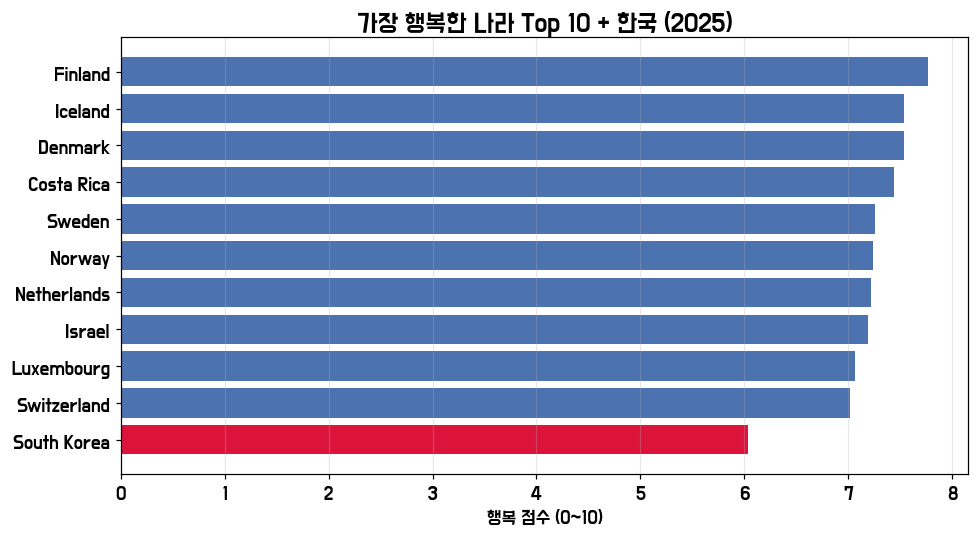

1위: Finland (7.76)
한국: 6.04점, 전체 158개국 중 73위


In [6]:
happy = pd.read_csv(data_path("world_happiness_owid.csv"))   # 세계 행복 보고서 CSV 읽기
h25 = happy[happy["year"] == 2025].dropna(subset=["cantril_ladder_score"]).copy()  # 2025년 + 점수 있는 나라만
h25 = h25.sort_values("cantril_ladder_score", ascending=False).reset_index(drop=True)  # 점수 높은 순 정렬

top10 = h25.head(10)                                  # 상위 10개국
kor = h25[h25["entity"] == "South Korea"]             # 한국 행만 뽑기
kor_rank = h25.index[h25["entity"] == "South Korea"][0] + 1   # 한국 순위 (인덱스는 0부터라 +1)

show = pd.concat([top10, kor])                        # 그래프에 그릴 대상 = 상위10 + 한국
colors = ["#4C72B0"] * len(top10) + ["crimson"]       # 상위10은 파랑, 한국만 빨강

plt.figure(figsize=(9, 5))
plt.barh(show["entity"], show["cantril_ladder_score"], color=colors)  # 나라별 행복점수 가로 막대
plt.gca().invert_yaxis()   # y축 뒤집기 → 1위가 맨 위로
plt.title("가장 행복한 나라 Top 10 + 한국 (2025)", fontsize=14)
plt.xlabel("행복 점수 (0~10)"); plt.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"1위: {top10.iloc[0]['entity']} ({top10.iloc[0]['cantril_ladder_score']:.2f})")   # 1위 나라·점수
print(f"한국: {kor.iloc[0]['cantril_ladder_score']:.2f}점, 전체 {len(h25)}개국 중 {kor_rank}위")  # 한국 점수·순위

**핀란드가 1위(7.76)**, 북유럽이 상위권을 휩쓸었습니다. 한국은 **6.04점, 73위** — 중상위권이지만 top과는 거리가 있죠.
빨간 막대 하나로 *"우리는 지금 여기"* 가 한눈에. 이렇게 **숫자에 색을 입히면 메시지가 강해집니다.**

## 5. ⚽ 국제 축구 150년 — 한국 대표팀의 전적 🔵

마지막 데이터는 축구입니다. **1872년부터 2026년까지** 전 세계 A매치 4.9만 경기 기록 —
그중 **한국 대표팀 1,008경기**의 승·무·패를 그려봅니다. (5교시 캡스톤에서 직접 분석할 데이터예요!)

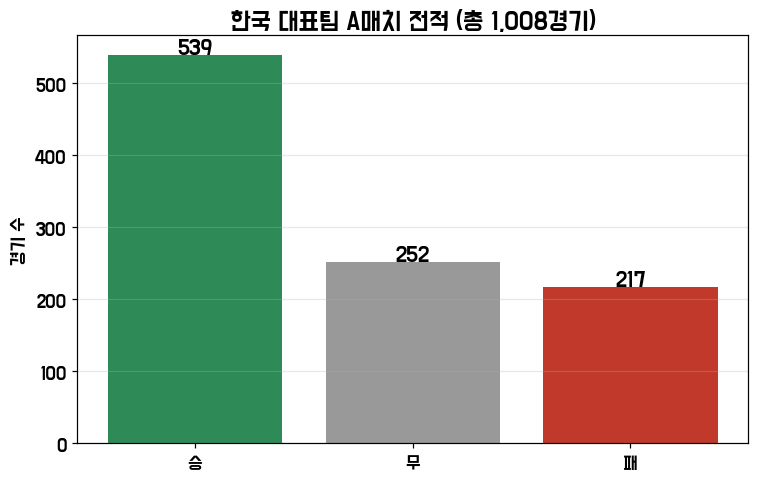

승 539 / 무 252 / 패 217  →  승률 53.5%
(참고) 2026 월드컵 진행 중이라 아직 안 치른 경기는 결측으로 빠져 있어요 — 그것도 데이터의 일부!


In [7]:
wc = pd.read_csv(DATA_BASE + "worldcup_results.csv")   # 국제 A매치 전체 결과 (5교시 캡스톤과 동일 데이터)
mask = (wc["home_team"] == "South Korea") | (wc["away_team"] == "South Korea")  # 한국이 홈 '또는' 원정인 경기
kor = wc[mask].dropna(subset=["home_score", "away_score"]).copy()  # 그중 점수가 기록된(이미 치른) 경기만

gf = np.where(kor["home_team"] == "South Korea", kor["home_score"], kor["away_score"])  # 한국이 '넣은' 골
ga = np.where(kor["home_team"] == "South Korea", kor["away_score"], kor["home_score"])  # 한국이 '먹은' 골
kor["결과"] = np.where(gf > ga, "승", np.where(gf == ga, "무", "패"))  # 골 비교로 승/무/패 판정
res = kor["결과"].value_counts().reindex(["승", "무", "패"])           # 승·무·패 개수 세기 (순서 고정)

plt.figure(figsize=(7, 4.5))
bars = plt.bar(res.index, res.values, color=["#2E8B57", "#999999", "#C0392B"])  # 승(초록)·무(회색)·패(빨강)
for b, v in zip(bars, res.values):                                             # 막대마다 위에 숫자 라벨
    plt.text(b.get_x() + b.get_width()/2, v + 5, f"{v}", ha="center", fontsize=12)  # 막대 중앙 위에 개수 표시
plt.title(f"한국 대표팀 A매치 전적 (총 {len(kor):,}경기)", fontsize=14)
plt.ylabel("경기 수"); plt.grid(axis="y", alpha=0.3)   # y축 이름 + 가로 격자
plt.tight_layout(); plt.show()

print(f"승 {res['승']} / 무 {res['무']} / 패 {res['패']}  →  승률 {res['승']/len(kor)*100:.1f}%")  # 승·무·패와 승률
print(f"(참고) 2026 월드컵 진행 중이라 아직 안 치른 경기는 결측으로 빠져 있어요 — 그것도 데이터의 일부!")

**1,008경기 중 539승(승률 53.5%)** — 절반 넘게 이겼네요!
참고로 *아직 안 치른 2026 월드컵 경기*는 점수가 비어 있어 자동으로 빠졌습니다.
이런 **'빈 칸(결측)'을 어떻게 다루느냐**가 3교시·5교시의 핵심 주제예요.

## 6. 🎆 한 장으로 모아 보기 — "데이터 분석이 다루는 세계"

방금 본 네 가지를 **한 화면에** 모아봅니다. 돈, 집, 행복, 스포츠 —
전혀 달라 보이는 주제가 **똑같은 도구 몇 줄**로 모두 그려집니다. 이게 데이터 분석의 힘입니다.

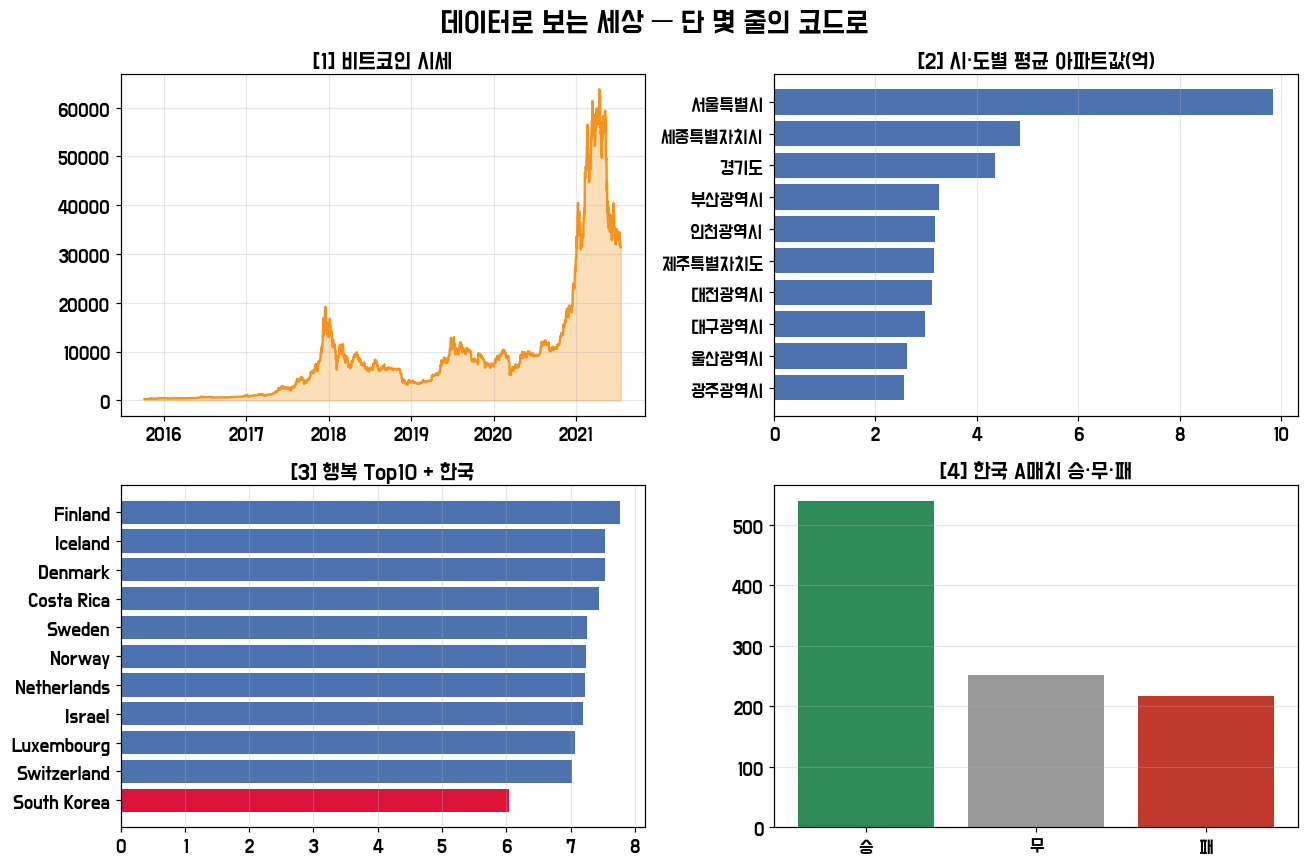

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))   # 2행 2열 = 그래프 4개를 한 화면에 (ax[행,열]로 접근)

# (1) 비트코인  — 앞에서 만든 btc 변수를 그대로 재사용
ax[0,0].fill_between(btc["Date"], btc["Close"], color="#F7931A", alpha=0.3)
ax[0,0].plot(btc["Date"], btc["Close"], color="#F7931A")
ax[0,0].set_title("[1] 비트코인 시세"); ax[0,0].grid(alpha=0.3)

# (2) 부동산 시도별  — 앞의 top(시도별 평균) 재사용
ax[0,1].barh(top.index[::-1], top.values[::-1], color="#4C72B0")
ax[0,1].set_title("[2] 시·도별 평균 아파트값(억)"); ax[0,1].grid(axis="x", alpha=0.3)

# (3) 세계 행복 Top + 한국  — 앞의 show 재사용 (한국만 빨강)
ax[1,0].barh(show["entity"], show["cantril_ladder_score"],
             color=["#4C72B0"]*len(top10)+["crimson"])
ax[1,0].invert_yaxis(); ax[1,0].set_title("[3] 행복 Top10 + 한국"); ax[1,0].grid(axis="x", alpha=0.3)

# (4) 한국 축구 전적  — 앞의 res(승·무·패) 재사용
ax[1,1].bar(res.index, res.values, color=["#2E8B57","#999999","#C0392B"])
ax[1,1].set_title("[4] 한국 A매치 승·무·패"); ax[1,1].grid(axis="y", alpha=0.3)

fig.suptitle("데이터로 보는 세상 — 단 몇 줄의 코드로", fontsize=16)   # 전체 큰 제목
plt.tight_layout(); plt.show()

돈·집·행복·축구. **주제는 달라도 '불러오기 → 그림으로 보기'라는 문법은 하나**입니다.
2교시부터는 이 문법을 여러분 손으로 직접 익힙니다.

## 🎯 1교시 마무리

오늘 우리는 **분석의 전체 흐름**을 멀리서 구경했습니다 —
돈·집·행복·축구 데이터를 *가져오고 → 화려한 그림으로 보고 → 질문을 던지는* 흐름을 함께 봤습니다.

도구(ChatGPT·에이전트)는 점점 똑똑해지지만, 가장 중요한 건 그대로입니다.

> ## "도구는 변해도, 좋은 질문을 던지고 결과를 해석하는 힘은 사람의 몫이다."

그 힘을 기르기 위해, **2교시부터 직접 데이터를 만져봅니다.** 🚀